In [1]:
# Cell 1: Setup & imports
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ID = "telco-portfolio"
DATASET_ID = "telco_dataset"
TABLE_ID = "features_network_kqi"
BUCKET_NAME = f"telco-portfolio-bucket-{datetime.now().strftime('%Y%m%d')}"

client = bigquery.Client(project=PROJECT_ID)

In [2]:
# Cell 2: Load data from BigQuery
query = f"""
SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
"""

df = client.query(query).to_dataframe()
print(f"Loaded {len(df)} rows")

/Users/macos/Study_burhanudin_2025/GCP/telco-ai-portfolio/venv_telco/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 14086 rows


In [3]:
# Cell 3: Prepare data for modeling (FIXED - No Data Leakage)
print("🔍 Memeriksa kolom yang tersedia...")

# List kolom yang harus di-drop (target dan kolom yang tidak boleh dipakai untuk training)
forced_drop = ['customerID', 'Churn', 'churn_label']

# Kolom yang mengandung informasi dari masa depan (data leakage)
# network_quality_score dihitung menggunakan Churn, jadi mengandung informasi target
leakage_columns = ['network_quality_score', 'quality_category', 'customer_segment']

# Gabungkan semua kolom yang akan di-drop
columns_to_drop = forced_drop + leakage_columns

# Hanya drop kolom yang benar-benar ada di dataframe
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

print(f"🗑️ Akan di-drop ({len(columns_to_drop)} kolom): {columns_to_drop}")

# Fitur (X) = semua kolom kecuali yang di-drop
X = df.drop(columns=columns_to_drop)

# Target (y) = churn_label
y = df['churn_label']

print(f"\n✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")
print(f"✅ Churn rate: {y.mean():.2%}")

# Tampilkan kolom fitur yang tersisa
print(f"\n📋 FITUR YANG DIGUNAKAN UNTUK TRAINING ({len(X.columns)} kolom):")
for i, col in enumerate(X.columns):
    print(f"   {i+1}. {col}")

🔍 Memeriksa kolom yang tersedia...
🗑️ Akan di-drop (5 kolom): ['customerID', 'Churn', 'churn_label', 'network_quality_score', 'customer_segment']

✅ Features shape: (14086, 22)
✅ Target shape: (14086,)
✅ Churn rate: 26.54%

📋 FITUR YANG DIGUNAKAN UNTUK TRAINING (22 kolom):
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. InternetService
   9. OnlineSecurity
   10. OnlineBackup
   11. DeviceProtection
   12. TechSupport
   13. StreamingTV
   14. StreamingMovies
   15. Contract
   16. PaperlessBilling
   17. PaymentMethod
   18. MonthlyCharges
   19. TotalCharges
   20. avg_throughput_mbps
   21. latency_ms
   22. drop_call_rate


In [4]:
# Cell 4: Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Categorical columns: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'TotalCharges']
Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
Encoded InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
Encoded OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
Encoded StreamingMovies: {'No': np.int64

In [5]:
# Cell 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

Train size: 11268
Test size: 2818
Churn rate in train: 26.54%
Churn rate in test: 26.54%


In [7]:
# Cell 6: Train XGBoost model with early stopping (Compatible version)
print("🚀 Training XGBoost model...")

# Hitung class weight untuk mengatasi imbalance (opsional)
scale_pos_weight = (len(y) - y.sum()) / y.sum()
print(f"⚖️ Scale pos weight (class imbalance): {scale_pos_weight:.2f}")

# Parameter model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=20  # Early stopping parameter langsung di sini
)

# Train dengan early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

print("✅ Model training completed!")
print(f"📊 Best iteration: {model.best_iteration if hasattr(model, 'best_iteration') else 'N/A'}")
print(f"📊 Best score: {model.best_score if hasattr(model, 'best_score') else 'N/A'}")

🚀 Training XGBoost model...
⚖️ Scale pos weight (class imbalance): 2.77


/Users/macos/Study_burhanudin_2025/GCP/telco-ai-portfolio/venv_telco/lib/python3.11/site-packages/xgboost/callback.py:385: UserWarning: [10:47:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.67478
[1]	validation_0-logloss:0.66035
[2]	validation_0-logloss:0.64762
[3]	validation_0-logloss:0.63332
[4]	validation_0-logloss:0.62013
[5]	validation_0-logloss:0.60814
[6]	validation_0-logloss:0.59743
[7]	validation_0-logloss:0.58756
[8]	validation_0-logloss:0.57975
[9]	validation_0-logloss:0.57149
[10]	validation_0-logloss:0.56425
[11]	validation_0-logloss:0.55758
[12]	validation_0-logloss:0.55149
[13]	validation_0-logloss:0.54469
[14]	validation_0-logloss:0.53896
[15]	validation_0-logloss:0.53356
[16]	validation_0-logloss:0.52852
[17]	validation_0-logloss:0.52368
[18]	validation_0-logloss:0.51890
[19]	validation_0-logloss:0.51485
[20]	validation_0-logloss:0.51134
[21]	validation_0-logloss:0.50778
[22]	validation_0-logloss:0.50406
[23]	validation_0-logloss:0.50083
[24]	validation_0-logloss:0.49797
[25]	validation_0-logloss:0.49540
[26]	validation_0-logloss:0.49299
[27]	validation_0-logloss:0.49042
[28]	validation_0-logloss:0.48808
[29]	validation_0-loglos

In [8]:
# Cell 7: Evaluate model
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print(f"🎯 AUC Score: {auc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Peringatan jika AUC terlalu tinggi
if auc > 0.95:
    print("\n⚠️ PERINGATAN: AUC > 0.95 sangat tinggi!")
    print("   Masih mungkin ada data leakage. Periksa kembali fitur yang digunakan.")
elif auc > 0.85:
    print("\n✅ AUC bagus! Model memiliki performa yang baik.")
elif auc > 0.75:
    print("\n👍 AUC cukup baik. Model dapat digunakan.")
else:
    print("\n⚠️ AUC rendah. Perlu perbaikan fitur atau tuning.")

🎯 AUC Score: 0.8765

📊 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.79      0.85      2070
       Churn       0.58      0.77      0.66       748

    accuracy                           0.79      2818
   macro avg       0.74      0.78      0.75      2818
weighted avg       0.82      0.79      0.80      2818


✅ AUC bagus! Model memiliki performa yang baik.


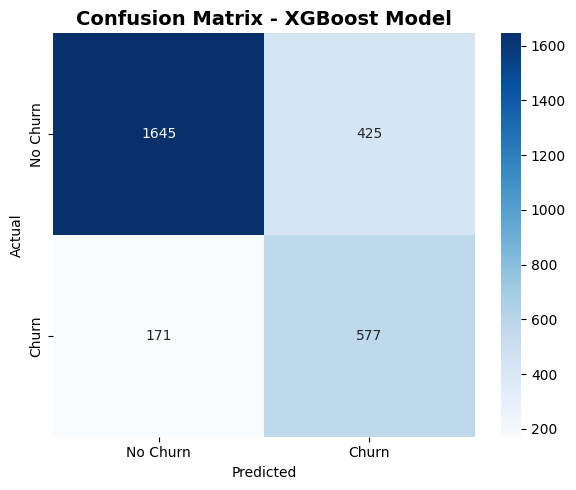

✅ Precision: 0.5758
✅ Recall: 0.7714
✅ F1-Score: 0.6594


In [9]:
# Cell 8: Confusion Matrix & Metrics (Pastikan ini jalan)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - XGBoost Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")
print(f"✅ F1-Score: {f1_score:.4f}")

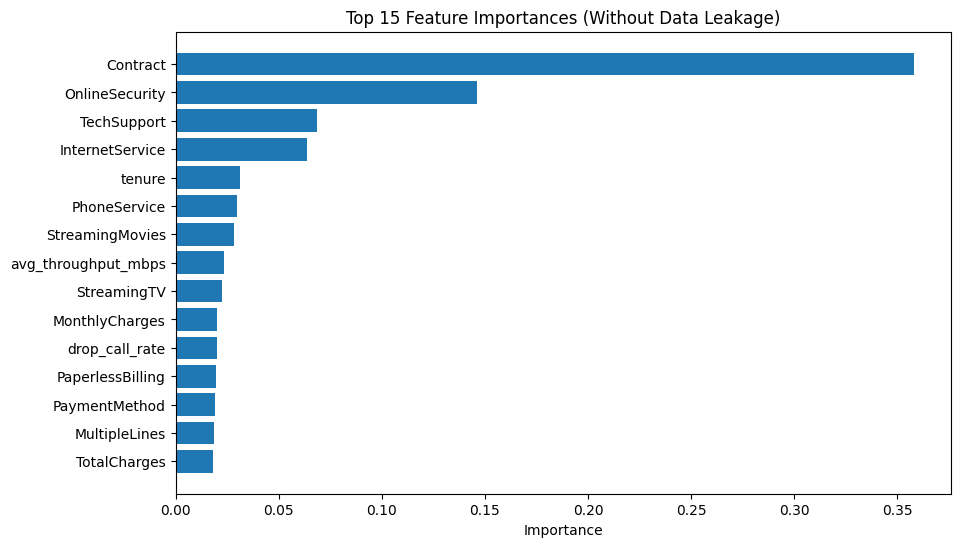


📊 TOP 10 MOST IMPORTANT FEATURES:
   15. Contract: 0.3580
   9. OnlineSecurity: 0.1461
   12. TechSupport: 0.0687
   8. InternetService: 0.0640
   5. tenure: 0.0312
   6. PhoneService: 0.0297
   14. StreamingMovies: 0.0285
   20. avg_throughput_mbps: 0.0232
   13. StreamingTV: 0.0224
   18. MonthlyCharges: 0.0200


In [10]:

# Cell 9: Feature Importance (Clean)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Without Data Leakage)')
plt.gca().invert_yaxis()
plt.show()

print("\n📊 TOP 10 MOST IMPORTANT FEATURES:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")

In [11]:
# Cell 10: Save model locally
model_filename = f'model_telco_churn_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)
    
print(f"✅ Model saved: {model_filename}")
print(f"✅ AUC: {auc:.4f}")

✅ Model saved: model_telco_churn_20260602_104805.pkl
✅ AUC: 0.8765


In [13]:
# Cell 11: Save model locally and to Cloud Storage (Auto-create bucket)
import pickle
import os
from datetime import datetime
from google.cloud import storage
from google.cloud.exceptions import NotFound

# Create model filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"model_telco_churn_{timestamp}.pkl"
local_model_path = f"./{model_filename}"

# 1. Save locally
with open(local_model_path, 'wb') as f:
    pickle.dump(model, f)

local_size = os.path.getsize(local_model_path)
print(f"✅ Model saved locally: {local_model_path}")
print(f"📦 Local file size: {local_size:,} bytes ({local_size/1024:.1f} KB)")

# 2. Setup Cloud Storage
BUCKET_NAME = f"telco-portfolio-bucket-20260602"  # Gunakan tanggal hari ini
storage_client = storage.Client(project="telco-portfolio")

# Cek apakah bucket ada, jika tidak buat baru
try:
    bucket = storage_client.get_bucket(BUCKET_NAME)
    print(f"✅ Bucket already exists: {BUCKET_NAME}")
except NotFound:
    print(f"📦 Bucket not found, creating: {BUCKET_NAME}")
    bucket = storage_client.create_bucket(BUCKET_NAME, location="us-central1")
    print(f"✅ Bucket created: {BUCKET_NAME}")

# 3. Upload to models folder
blob = bucket.blob(f"models/{model_filename}")
blob.upload_from_filename(local_model_path)

print(f"✅ Model uploaded to Cloud Storage:")
print(f"   gs://{BUCKET_NAME}/models/{model_filename}")

# 4. Save also as 'latest_model.pkl'
latest_blob = bucket.blob("models/latest_model.pkl")
latest_blob.upload_from_filename(local_model_path)
print(f"✅ Also saved as: gs://{BUCKET_NAME}/models/latest_model.pkl")

# 5. Save model metadata
model_metadata = {
    'model_name': model_filename,
    'timestamp': timestamp,
    'auc_score': auc if 'auc' in dir() else 0,
    'precision': precision if 'precision' in dir() else 0,
    'recall': recall if 'recall' in dir() else 0,
    'f1_score': f1_score if 'f1_score' in dir() else 0,
    'features': list(X.columns) if 'X' in dir() else [],
    'bucket': BUCKET_NAME,
    'local_path': local_model_path,
    'gcs_path': f"gs://{BUCKET_NAME}/models/{model_filename}"
}

import json
metadata_blob = bucket.blob(f"models/model_metadata_{timestamp}.json")
metadata_blob.upload_from_string(json.dumps(model_metadata, indent=2))

print(f"✅ Model metadata saved to Cloud Storage")
print(f"\n🎯 Model successfully saved!")

✅ Model saved locally: ./model_telco_churn_20260602_105004.pkl
📦 Local file size: 741,027 bytes (723.7 KB)
📦 Bucket not found, creating: telco-portfolio-bucket-20260602
✅ Bucket created: telco-portfolio-bucket-20260602
✅ Model uploaded to Cloud Storage:
   gs://telco-portfolio-bucket-20260602/models/model_telco_churn_20260602_105004.pkl
✅ Also saved as: gs://telco-portfolio-bucket-20260602/models/latest_model.pkl
✅ Model metadata saved to Cloud Storage

🎯 Model successfully saved!


In [14]:
# Cell 12: Verification & Business Summary (Fixed)
print("=" * 70)
print("📊 MODEL TRAINING COMPLETE - SUMMARY")
print("=" * 70)

print(f"""
🎯 MODEL PERFORMANCE:
   AUC Score: {auc:.4f} ({auc*100:.2f}%)
   Precision: {precision:.4f}
   Recall:    {recall:.4f}
   F1-Score:  {f1_score:.4f}

📁 MODEL LOCATIONS:
   Local:     {local_model_path}
   Cloud:     gs://{BUCKET_NAME}/models/{model_filename}
   Latest:    gs://{BUCKET_NAME}/models/latest_model.pkl

🔍 TOP 5 FEATURE IMPORTANCES:
""")

for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")

print("""
💡 BUSINESS RECOMMENDATIONS:
   1. Prioritize network quality improvement for customers with score < 40
   2. Target month-to-month Fiber customers with retention programs
   3. Focus customer success efforts on first 6 months of tenure

📋 NEXT STEPS:
   1. Deploy model to Vertex AI Endpoint (Notebook 5)
   2. Create Looker Studio Dashboard (Notebook 6)
   3. Share portfolio with recruiter
""")

print("=" * 70)
print("✅ Notebook 4 Selesai! Model siap untuk dideploy ke Vertex AI.")
print("=" * 70)

📊 MODEL TRAINING COMPLETE - SUMMARY

🎯 MODEL PERFORMANCE:
   AUC Score: 0.8765 (87.65%)
   Precision: 0.5758
   Recall:    0.7714
   F1-Score:  0.6594

📁 MODEL LOCATIONS:
   Local:     ./model_telco_churn_20260602_105004.pkl
   Cloud:     gs://telco-portfolio-bucket-20260602/models/model_telco_churn_20260602_105004.pkl
   Latest:    gs://telco-portfolio-bucket-20260602/models/latest_model.pkl

🔍 TOP 5 FEATURE IMPORTANCES:

   15. Contract: 0.3580
   9. OnlineSecurity: 0.1461
   12. TechSupport: 0.0687
   8. InternetService: 0.0640
   5. tenure: 0.0312

💡 BUSINESS RECOMMENDATIONS:
   1. Prioritize network quality improvement for customers with score < 40
   2. Target month-to-month Fiber customers with retention programs
   3. Focus customer success efforts on first 6 months of tenure

📋 NEXT STEPS:
   1. Deploy model to Vertex AI Endpoint (Notebook 5)
   2. Create Looker Studio Dashboard (Notebook 6)
   3. Share portfolio with recruiter

✅ Notebook 4 Selesai! Model siap untuk dideploy 